In [ ]:
#This notebook generates all figures comprising Figure3 in the paper

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pyrenn
sns.set(style='ticks')
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from scipy.interpolate import griddata
from scipy.stats import spearmanr
from matplotlib.pyplot import figure
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from pickle import load
import matplotlib.gridspec as gridspec
import ast
import sys
BMS_path='../bin/'
sys.path.append(BMS_path + 'no_degeneracy/')
sys.path.append(BMS_path + 'no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par

#Colors
#----------------------------------------------
colors_june={'0.5x':['#fee0d2', '#deebf7'],
       '1x':['#fc9272', '#9ecae1'],
       '2x':['#de2d26', '#3182bd'] }

color_noise=sns.color_palette("colorblind")[5]
color_data='#636363'
color_bms=colors_june['2x'][1]
color_ann=colors_june['2x'][0]
#-----------------------------------------------

In [55]:
#A function to return mdl models from traces
#------------------------------------------------------
def get_mdl(df_var, trace_var,dimensions=False ):
    
    #Parameters to read models
    if dimensions==True:
         VARS = ['x','y',]
         prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv2.np10.2016-09-09 18:49:42.600380.dat')
    else:
        VARS = ['x',]
        prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')

    #one or two dimensional nguyen functions
    try:
        x = df_var[[c for c in VARS]].copy()
        y=df_var.z_noise
    except KeyError:
        VARS = ['x1',]
        x = df_var[[c for c in VARS]].copy()
        y=df_var.y_noise
        
    
    minrow = trace_var[trace_var.H == min(trace_var.H)].iloc[0]
    minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)
    
    tvar= Tree(
        variables=list(x.columns),
        parameters=['a%d' % i for i in range(NPAR)],
        x=x, y=y,
        prior_par=prior_par,
        max_size=200,
        from_string=minexpr,
    )

    tvar.set_par_values(deepcopy(minparvals))
    x_var=x;y_var=y
    
    return tvar, x_var, y_var
#------------------------------------------------------

#Figure settings
#--------------------------------

#Paths, extensions, and figure size
#--------------------------------
output_path='../results/paper_figures/figure3/'      
extensions=['.svg', '.png']    
#Define figure size in cm
cm = 1/2.54 #convert inch to cm
width = 16*cm; height=16*cm 
#--------------------------------

#Text and figure sizes  
#--------------------------------
size_axis=16;size_ticks=14;size_title=16
line_w=3;marker_s=8
#--------------------------------

#ticks and limits for ng1 functions
#--------------------------------
xtick_labels_ng1=[-1, 0, 1 ];ytick_labels_ng1=[ -3, 0, 3, 6.0]
xmin_ng1=-1.1;xmax_ng1=1.1;ymin_ng1=-3.25;ymax_ng1=8
#--------------------------------

#ticks and limits for ng10 functions
#--------------------------------
xtick_labels_ng10=[0, 0.5, 1 ];ytick_labels_ng10=[ 0, 0.5, 1.0];ztick_labels_ng10=[ 0, 0.5, 1.0]
xmin_ng10=-0.1;xmax_ng10=1.1;ymin_ng10=-0.1;ymax_ng10=1.1;
zmin_ng10=-0.1;zmax_ng10=1

ticks={1:{'x':[0, 0.5, 1], 'y':[ -3, 0, 3, 6.0]}, 5:{'x':[-1, 0, 1], 'y':[-0.75,-0.5, -0.25]}, 
       7:{'x':[0,1,2,], 'y': [1,2,3]}, 8:{'x':[0,2,4], 'y':[0, 1, 2]}, 
       10:{'x':[0,0.5,1], 'y':[0,0.5,1], 'z':[0,0.5,1] } }

limits={1:{'x':[-1.1,1.1], 'y':[-3.25, 8]}, 5:{'x':[-1.2,1.2], 'y':[-0.8,-0.2]}, 
        7:{'x':[-0.1,2.1], 'y': [0.4,3.1]}, 8:{'x':[-0.1,4.2], 'y':[-0.1, 2.5]}, 
        10:{'x':[-0.1,1.1], 'y':[-0.1,1.1], 'z':[-0.1,1.1] } } 


#plt.xlim(-1.1, 1.1);plt.ylim(-2.6,5.1)
#--------------------------------

#nguyen title dict
titles={1: r'$y_1=3.39 x^3 + 2.12 x^2 +1.78x$',
        5: r'$y_5=\sin(x^2) \cos(x)$', 
        7: r'$y_7=\log(x+1.4) + \log(x^2 + 1.3)$',
        8: r'$y_8=\sqrt{1.23x}$',
        10:r'$y_{10}=\sin(1.5x) \cos(0.5y)$' }

In [56]:
#Read Nguyen data

#Read nguyen data
#-------------------------------------------------------------------------------
n=8
sigma=0.16;
realization=1

NPAR=10 #10, 20
steps=50000
path_nguyen_nn= '../data/nns/nguyen/'
file_model_ng1= path_nguyen_nn + 'NN_no_overfit_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
dng1=pd.read_csv(file_model_ng1,index_col=0)
#-------------------------------------------------------------------------------

#Read n1 trace
#-------------------------------------------------------------------------------

dng1=dng1[dng1['rep']==n]
#Read bms trace for nguyen n
path_nguyen_bms='../data/MSTraces/nguyen/'
trace_ng=path_nguyen_bms + 'BMS_nguyen_n_' + str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_id_0_trace_'+str(steps)+'_prior_10'+ '.csv'
trace=pd.read_csv(trace_ng, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])
t1,x1,y1=get_mdl(dng1, trace)
dng1=dng1.reset_index(drop=True)
#-------------------------------------------------------------------------------


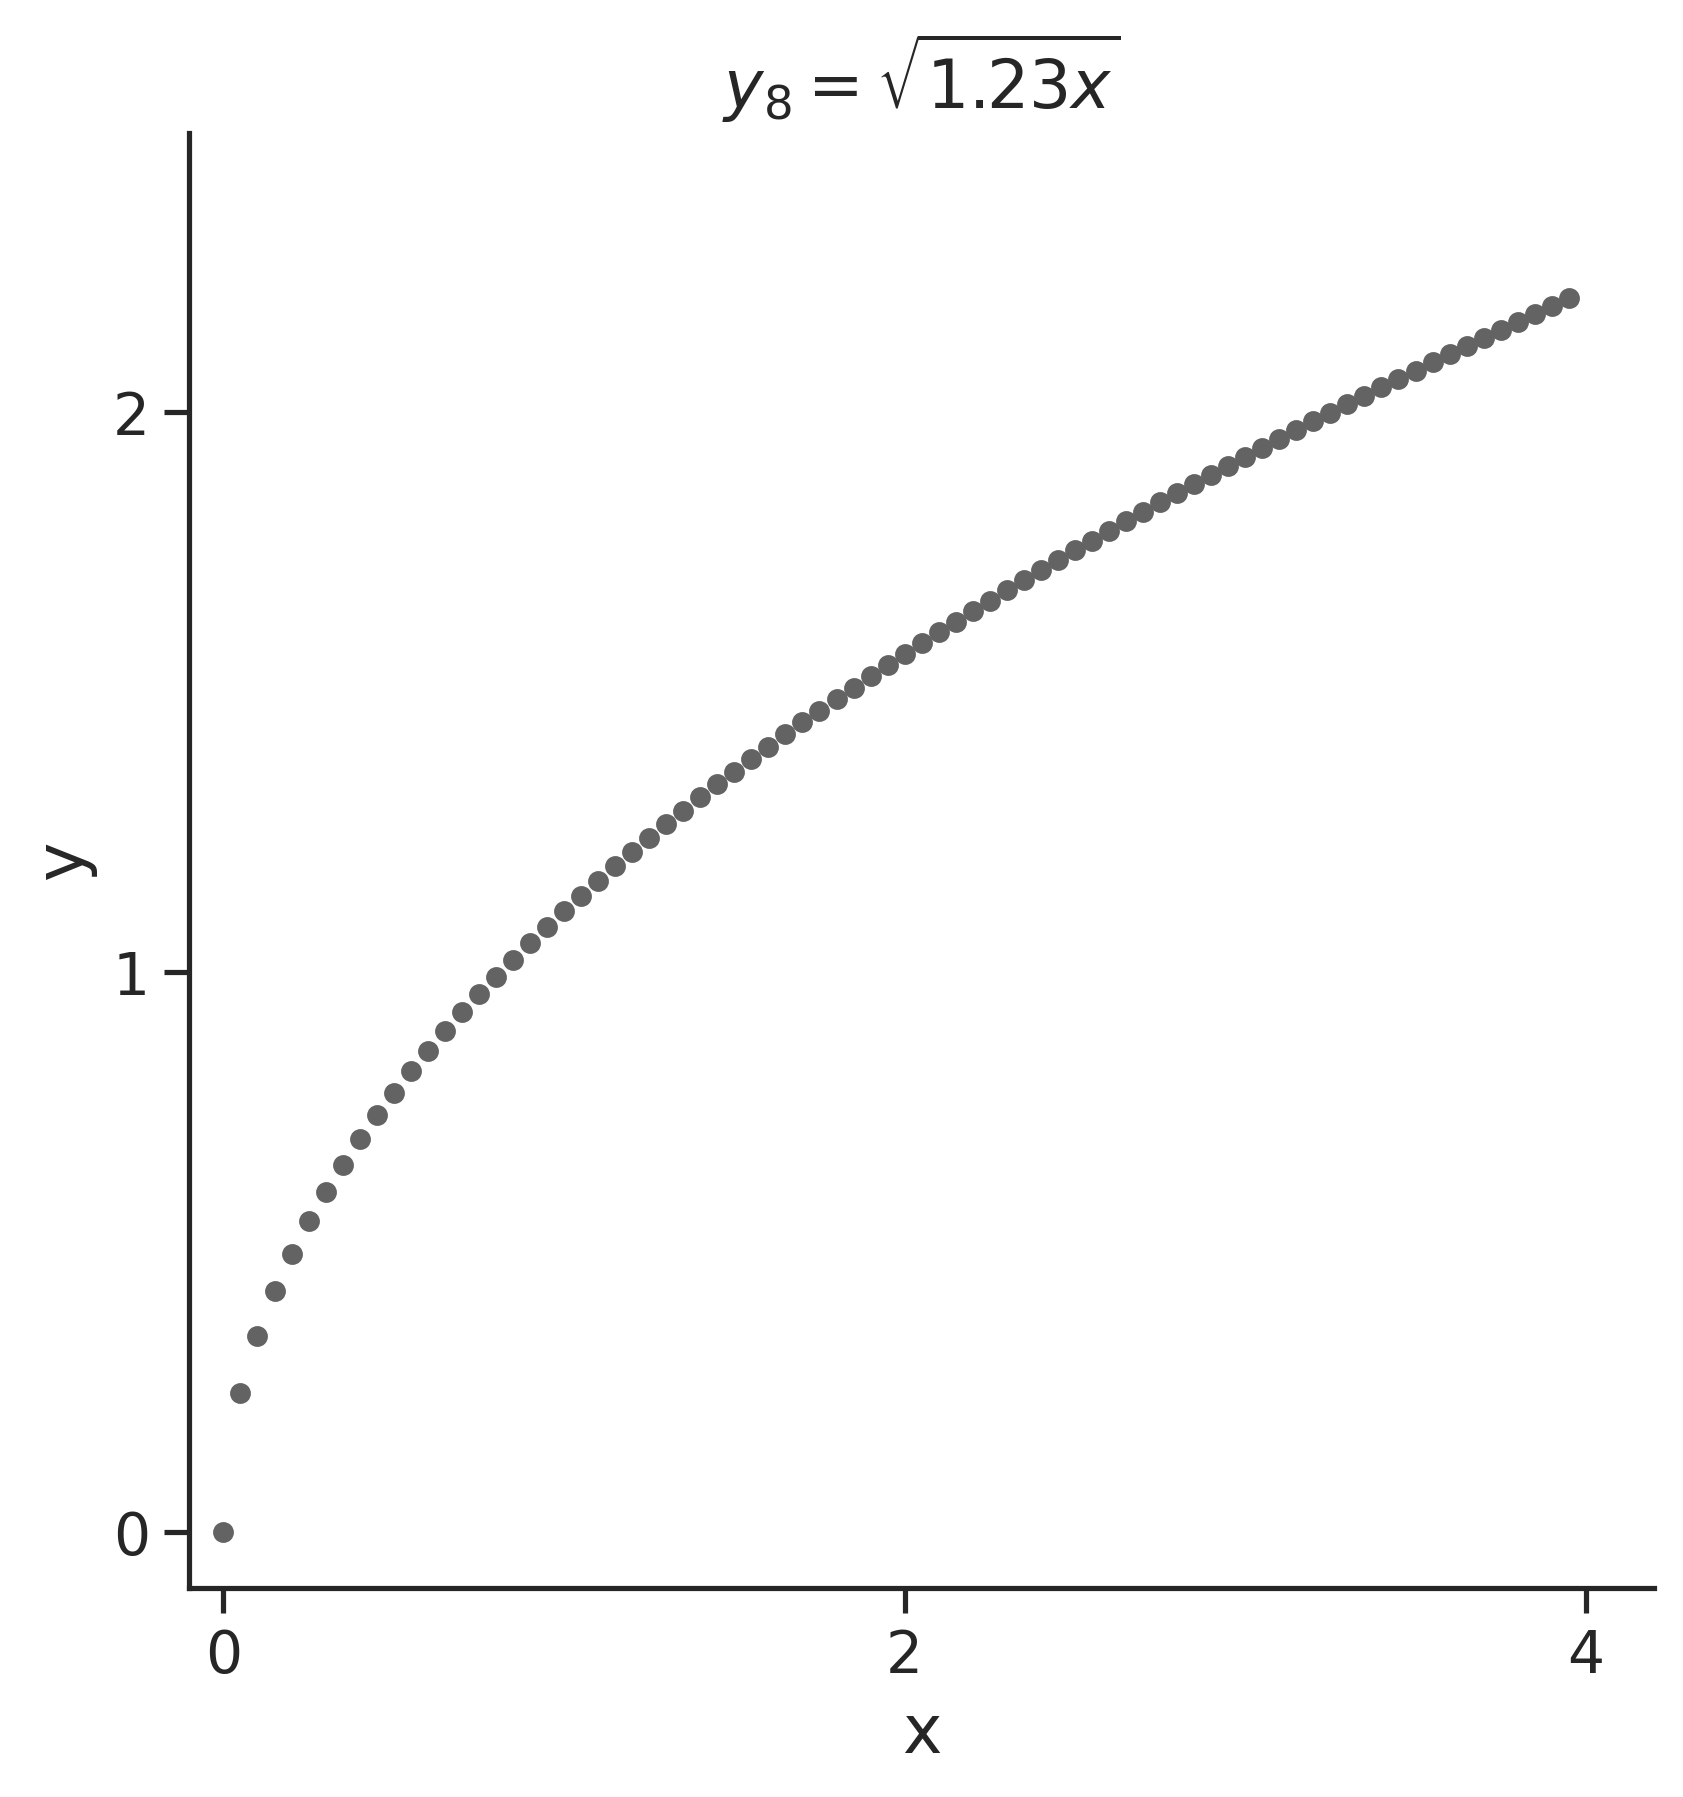

In [57]:
#Plot signal
#-------------------------------------------------------------------------------
fig=figure(figsize=(width,height), dpi=300) 

if n==10:
    ax = plt.figure().add_subplot(projection='3d')
    
    #ax_04 = plt.subplot(gs[1:3,1], projection='3d')
    #plt.title(r'$y_{10}=\sin(1.5x) \cos(0.5y)$',fontsize=size_title)
    ax.plot(dng1.x, dng1.y, dng1.z, '.', markersize=marker_s, color=color_data)
    print(ticks[n]['x'])
    print(ticks[n]['x'])
    ax.set_xticks(ticks[n]['x']);ax.set_yticks(ticks[n]['y']);ax.set_zticks(ticks[n]['z'])
    ax.set_xlabel('x',fontsize=size_axis);ax.set_ylabel('y',fontsize=size_axis);ax.set_zlabel('z',fontsize=size_axis)

else: 
    plt.plot(dng1.x,dng1.z, '.', markersize=marker_s, color=color_data)
    plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
    plt.xticks(ticks[n]['x'], fontsize=size_ticks);plt.yticks(ticks[n]['y'], fontsize=size_ticks)
    plt.xlim(limits[n]['x'][0], limits[n]['x'][1]);plt.ylim(limits[n]['y'][0], limits[n]['y'][1])

plt.title(titles[n],fontsize=size_title)
sns.despine()

namefig=str(n) + '_signal'
plt.savefig(output_path + namefig +'.svg',dpi=300)
#-------------------------------------------------------------------------------

,x,y,z,rep,noise,z_noise,zmodel
0,0.00,0.0,0.000000,8,0.010131,0.010131,0.242202
1,0.05,0.0,0.247992,8,0.188183,0.436175,0.301363
2,0.10,0.0,0.350714,8,0.095271,0.445985,0.361762
3,0.15,0.0,0.429535,8,-0.033780,0.395755,0.422556
4,0.20,0.0,0.495984,8,0.150168,0.646152,0.482922
...,...,...,...,...,...,...,...
75,3.75,0.0,2.147673,8,-0.101697,2.045976,2.254939
76,3.80,0.0,2.161944,8,-0.174326,1.987618,2.274451
77,3.85,0.0,2.176120,8,0.008105,2.184225,2.293814
78,3.90,0.0,2.190205,8,-0.040601,2.149604,2.313025


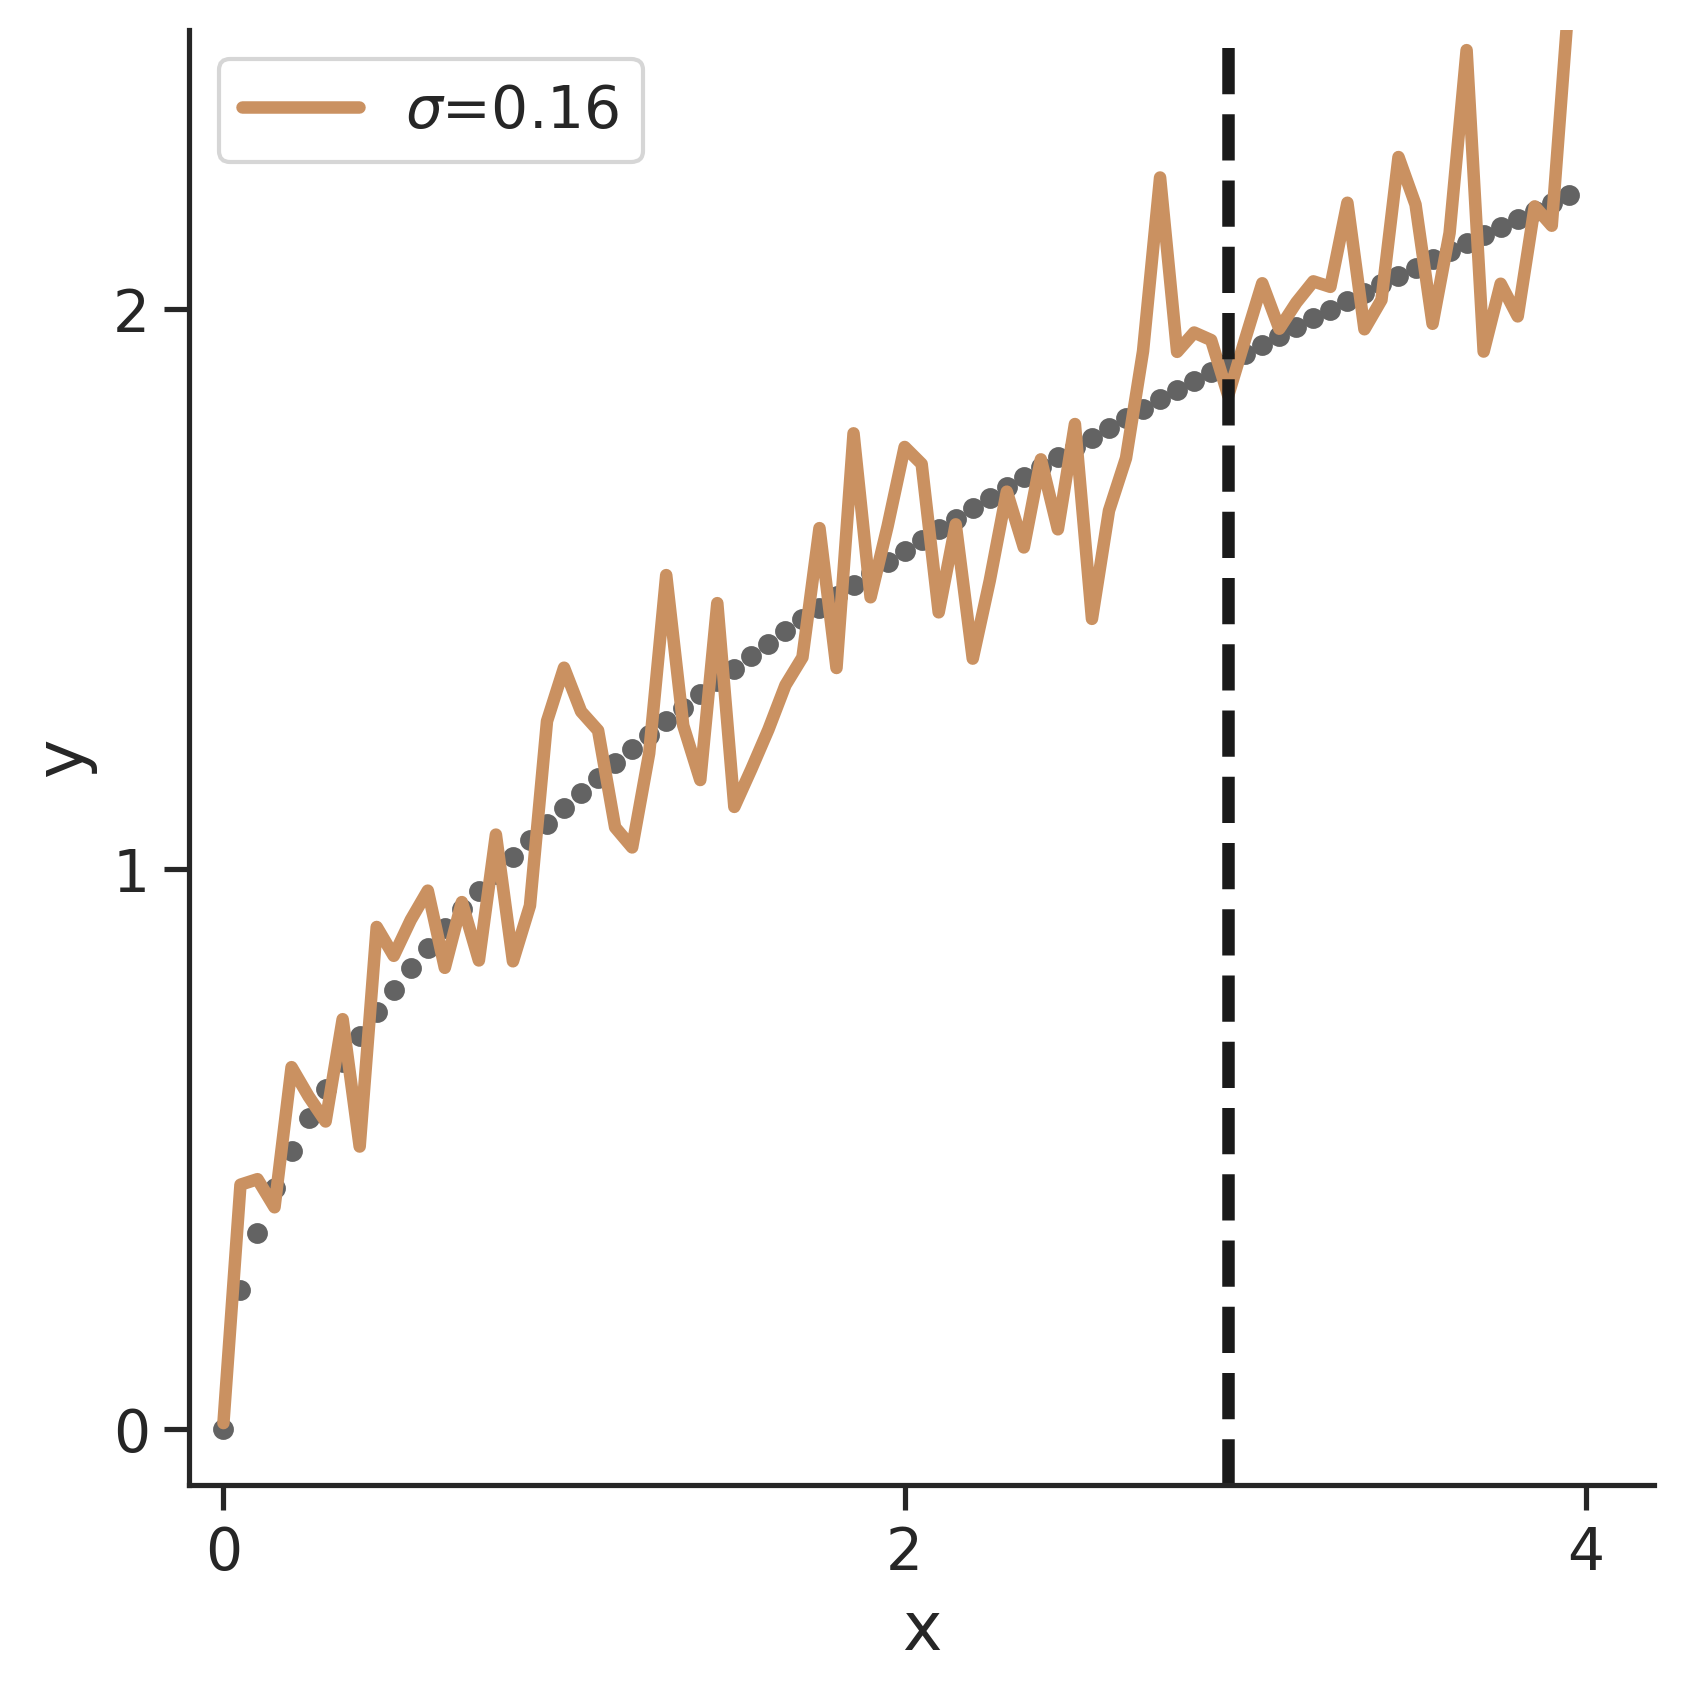

In [58]:
#Plot noise
#-------------------------------------------------------------------------------                                                                                                                                   
fig=figure(figsize=(width,height), dpi=300) 

if n==10:
    ax = plt.figure().add_subplot(projection='3d')
    ax.plot(dng1.x, dng1.y, dng1.z, '.', markersize=marker_s, color=color_data)
    ax.plot(dng1.x, dng1.y, dng1.z_noise, linewidth=line_w,color=color_noise, label=r'$\sigma$='+str(sigma))
    ax.set_xticks(ticks[n]['x']);ax.set_yticks(ticks[n]['y']);ax.set_zticks(ticks[n]['z'])
    ax.set_xlabel('x',fontsize=size_axis);ax.set_ylabel('y',fontsize=size_axis);ax.set_zlabel('z',fontsize=size_axis)

else: 
    train_size=60
    display(dng1)
    train_border=dng1.loc[train_size-1]['x']
    plt.plot(dng1.x,dng1.z, '.', markersize=marker_s, color=color_data)
    plt.plot(dng1.x,dng1.z_noise, linewidth=line_w,color=color_noise, label=r'$\sigma$='+str(sigma))
    plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')
    plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
    plt.xticks(ticks[n]['x'], fontsize=size_ticks);plt.yticks(ticks[n]['y'], fontsize=size_ticks)
    plt.legend(loc='best', fontsize=size_ticks)

    plt.xlim(limits[n]['x'][0], limits[n]['x'][1]);plt.ylim(limits[n]['y'][0], limits[n]['y'][1])

sns.despine()

namefig=str(n) + '_noise'
plt.savefig(output_path + namefig +'.svg',dpi=300)

In [2]:
#Plot ann+bms predictions
dplot = deepcopy(dng1)
dplot['ybms'] = t1.predict(x1)

#Compute rmse errors
rmse_nn_train=root_mean_squared_error(dplot.loc[:train_size-1]['zmodel'],dplot.loc[:train_size -1]['z'])
rmse_nn_test=root_mean_squared_error(dplot.loc[train_size-1:]['zmodel'],dplot.loc[train_size -1:]['z'])

try:
    rmse_mdl_train=root_mean_squared_error(dplot.loc[:train_size-1]['ybms'],dplot.loc[:train_size-1]['z'])
except ValueError:
    rmse_mdl_train=np.inf
try:
    rmse_mdl_test =root_mean_squared_error(dplot.loc[train_size-1:]['ybms'],dplot.loc[train_size-1:]['z'])
except ValueError:
    rmse_mdl_test=np.inf


#Plot figure
fig=figure(figsize=(width,height), dpi=300)  

if n==10:
    ax = plt.figure().add_subplot(projection='3d')
    ax.plot(dng1.x, dng1.y, dng1.z, '.', markersize=marker_s, color=color_data)
    ax.plot(dng1.x, dng1.y, dng1.z_noise, linewidth=line_w,color=color_noise, label=r'$\sigma$='+str(sigma))
    ax.plot(dng1['x'], dng1['zmodel'],linewidth=line_w, color=color_ann, label="ann, $f'$" ) 
    ax.plot(dplot.x, dplot.ybms, linewidth=line_w,color=color_bms,label="BMS, $f''$" )
    ax.set_xticks(ticks[n]['x']);ax.set_yticks(ticks[n]['y']);ax.set_zticks(ticks[n]['z'])
    ax.set_xlabel('x',fontsize=size_axis);ax.set_ylabel('y',fontsize=size_axis);ax.set_zlabel('z',fontsize=size_axis)

else:
    plt.plot(dng1['x'], dng1['zmodel'],linewidth=line_w, color=color_ann, label="ann, $f'$" ) 
    plt.plot(dplot.x, dplot.ybms, linewidth=line_w,color=color_bms,label="BMS, $f''$" )
    plt.plot(dng1['x'], dng1['z'],'.', markersize=marker_s, color=color_data) 
    plt.plot(dng1['x'], dng1['z_noise'],linewidth=line_w, markersize=marker_s, color=color_noise,label=r'$\sigma$='+str(sigma)) 

    train_size=60
    train_border=dng1.loc[train_size-1]['x']
    plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')
    plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
    plt.xticks(ticks[n]['x'], fontsize=size_ticks);plt.yticks(ticks[n]['y'], fontsize=size_ticks)
    plt.xlim(limits[n]['x'][0], limits[n]['x'][1]);plt.ylim(limits[n]['y'][0], limits[n]['y'][1])


plt.legend(loc='best', fontsize=size_ticks)
#set limits and layout
sns.despine()

#Save figure
namefig=str(n)+'_nguyen_noise_predictions' + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)
    

plt.savefig(output_path + namefig +'.svg',dpi=300)


display(t1,t1.par_values)

NameError: name 'dng1' is not defined

In [62]:
#General results

In [63]:
#Approximation errors
#--------------------------------------------------------------------------------------------------------------
errors_approximation=pd.read_csv('../data/'+ 'all_errors_nguyen' + '.csv',index_col=0)
#only take rmse results
columns=["sigma", "function","rmse_nn_train", "rmse_nn_test", "rmse_mdl_train", "rmse_mdl_test","r"]
errors_approximation=errors_approximation[columns]
#Melt dataframes and divide train and test
errors_train=errors_approximation[["sigma", "function","rmse_nn_train", "rmse_mdl_train","r"]]
#change name columns for legends
errors_train=errors_train.rename(columns={"rmse_nn_train": "rmse-ann", "rmse_mdl_train": "rmse-bms"})
errors_train=pd.melt(errors_train,id_vars=["sigma","function","r"], var_name="error approx",value_name= "value_train")

#Errors test. Not used, in principle
errors_test=errors_approximation[["sigma", "function","rmse_nn_test", "rmse_mdl_test","r"]]
errors_test=pd.melt(errors_test,id_vars=["sigma","function", "r"], var_name="error_test", value_name= "value_test")
#--------------------------------------------------------------------------------------------------------------

#Inter-extrapolation errors
#--------------------------------------------------------------------------------------------------------------
errors_inter_extra=pd.read_csv('../data/'+ 'all_errors_nguyen_interpolation' + '.csv',index_col=0)
#only take rmse results
columns=["sigma", "function","rmse_nn_interp.", "rmse_nn_extrap.", "rmse_mdl_interp.", "rmse_mdl_extrap.","r"]

#interpolation
errors_inter=errors_inter_extra[["sigma", "function","rmse_nn_interp.", "rmse_mdl_interp.","r"]]
errors_inter=errors_inter.rename(columns={"rmse_nn_interp.": "rmse-ann", "rmse_mdl_interp.": "rmse-bms"})#change column names for legends
errors_inter=pd.melt(errors_inter,id_vars=["sigma","function","r"], var_name="error interp",value_name= "value_interp")

#extrapolation
errors_extra=errors_inter_extra[["sigma", "function","rmse_nn_extrap.", "rmse_mdl_extrap.","r"]]
errors_extra=errors_extra.rename(columns={"rmse_nn_extrap.": "rmse-ann", "rmse_mdl_extrap.": "rmse-bms"})#change column names for legends
errors_extra=pd.melt(errors_extra,id_vars=["sigma","function", "r"], var_name="error extrap", value_name= "value_extrap")
#--------------------------------------------------------------------------------------------------------------
display(errors_inter)

,sigma,function,r,error interp,value_interp
0,0.00,1,0,rmse-ann,0.006952
1,0.00,1,1,rmse-ann,0.004161
2,0.00,1,2,rmse-ann,0.007171
3,0.02,1,0,rmse-ann,0.016572
4,0.02,1,1,rmse-ann,0.004839
...,...,...,...,...,...
325,0.18,10,1,rmse-bms,0.041766
326,0.18,10,2,rmse-bms,0.037522
327,0.20,10,0,rmse-bms,0.045421
328,0.20,10,1,rmse-bms,0.102974


In [64]:
#Select function to plot
errors_train_plot=errors_train[errors_train['function']==n]

errors_inter_plot=errors_inter[errors_inter['function']==n]
errors_extra_plot=errors_extra[errors_extra['function']==n]

In [65]:
#Plot overall results                                                   
m_size=10
markers = {'rmse_nn_train': 'o', 'rmse_mdl_train': 's'}
resamples=100000; bs_seed=1111 # bootstrap and seed
ymin=1e-17;ymax=10

6.299212598425196 6.299212598425196


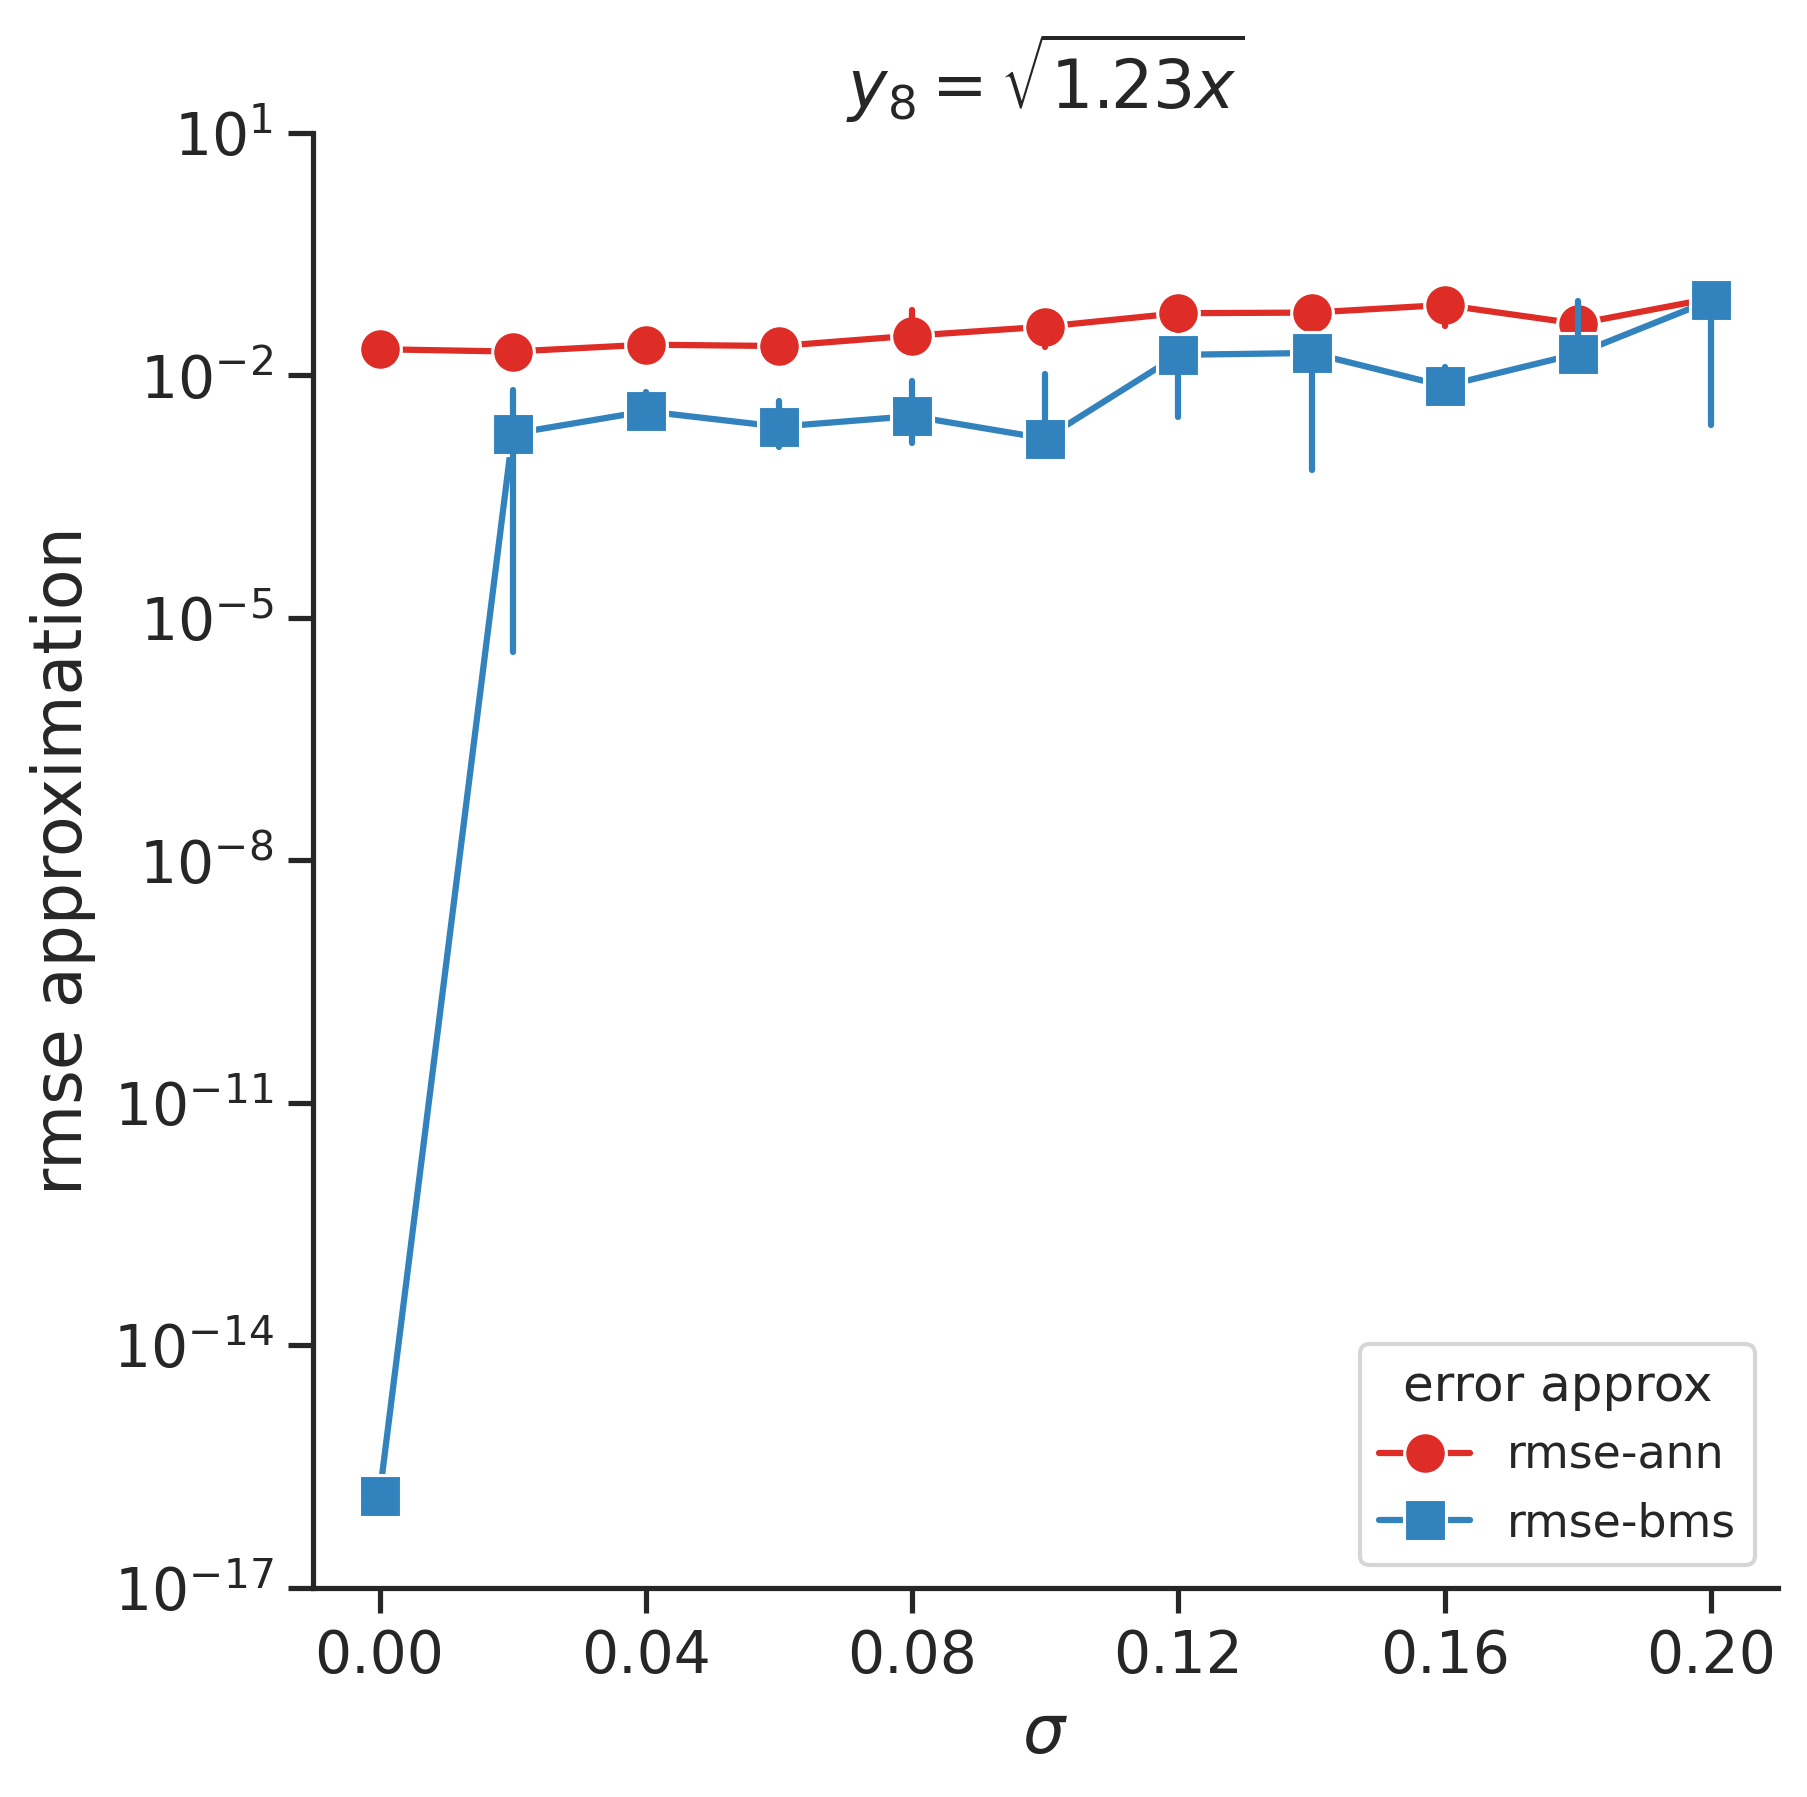

In [66]:
#approximation
#-------------------------------------------------------------------------------------------------------------------
fig=figure(figsize=(width,height), dpi=300)
print(width, height)

sns.lineplot(
        data=errors_train_plot, x='sigma', y='value_train', hue='error approx', style='error approx',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_train'], markers['rmse_mdl_train']], dashes=False, markersize=m_size, legend="full", 
        palette=[color_ann, color_bms])

#labels, limits, and ticks
plt.title(titles[n],fontsize=size_title)
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse approximation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
xtick_labels=np.arange(0.0,0.22,0.04)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()
plt.ylim(ymin,ymax)

sns.despine()

namefig_app='approximation_' + str(n) 
plt.savefig(output_path+namefig_app + '.svg',dpi=300)
#-------------------------------------------------------------------------------------------------------------------

6.299212598425196 6.299212598425196


,sigma,function,r,error interp,value_interp
99,0.00,8,0,rmse-ann,0.013619
100,0.00,8,1,rmse-ann,0.012829
101,0.00,8,2,rmse-ann,0.014876
102,0.02,8,0,rmse-ann,0.012214
103,0.02,8,1,rmse-ann,0.012940
...,...,...,...,...,...
292,0.18,8,1,rmse-bms,0.018650
293,0.18,8,2,rmse-bms,0.083448
294,0.20,8,0,rmse-bms,0.085696
295,0.20,8,1,rmse-bms,0.084230


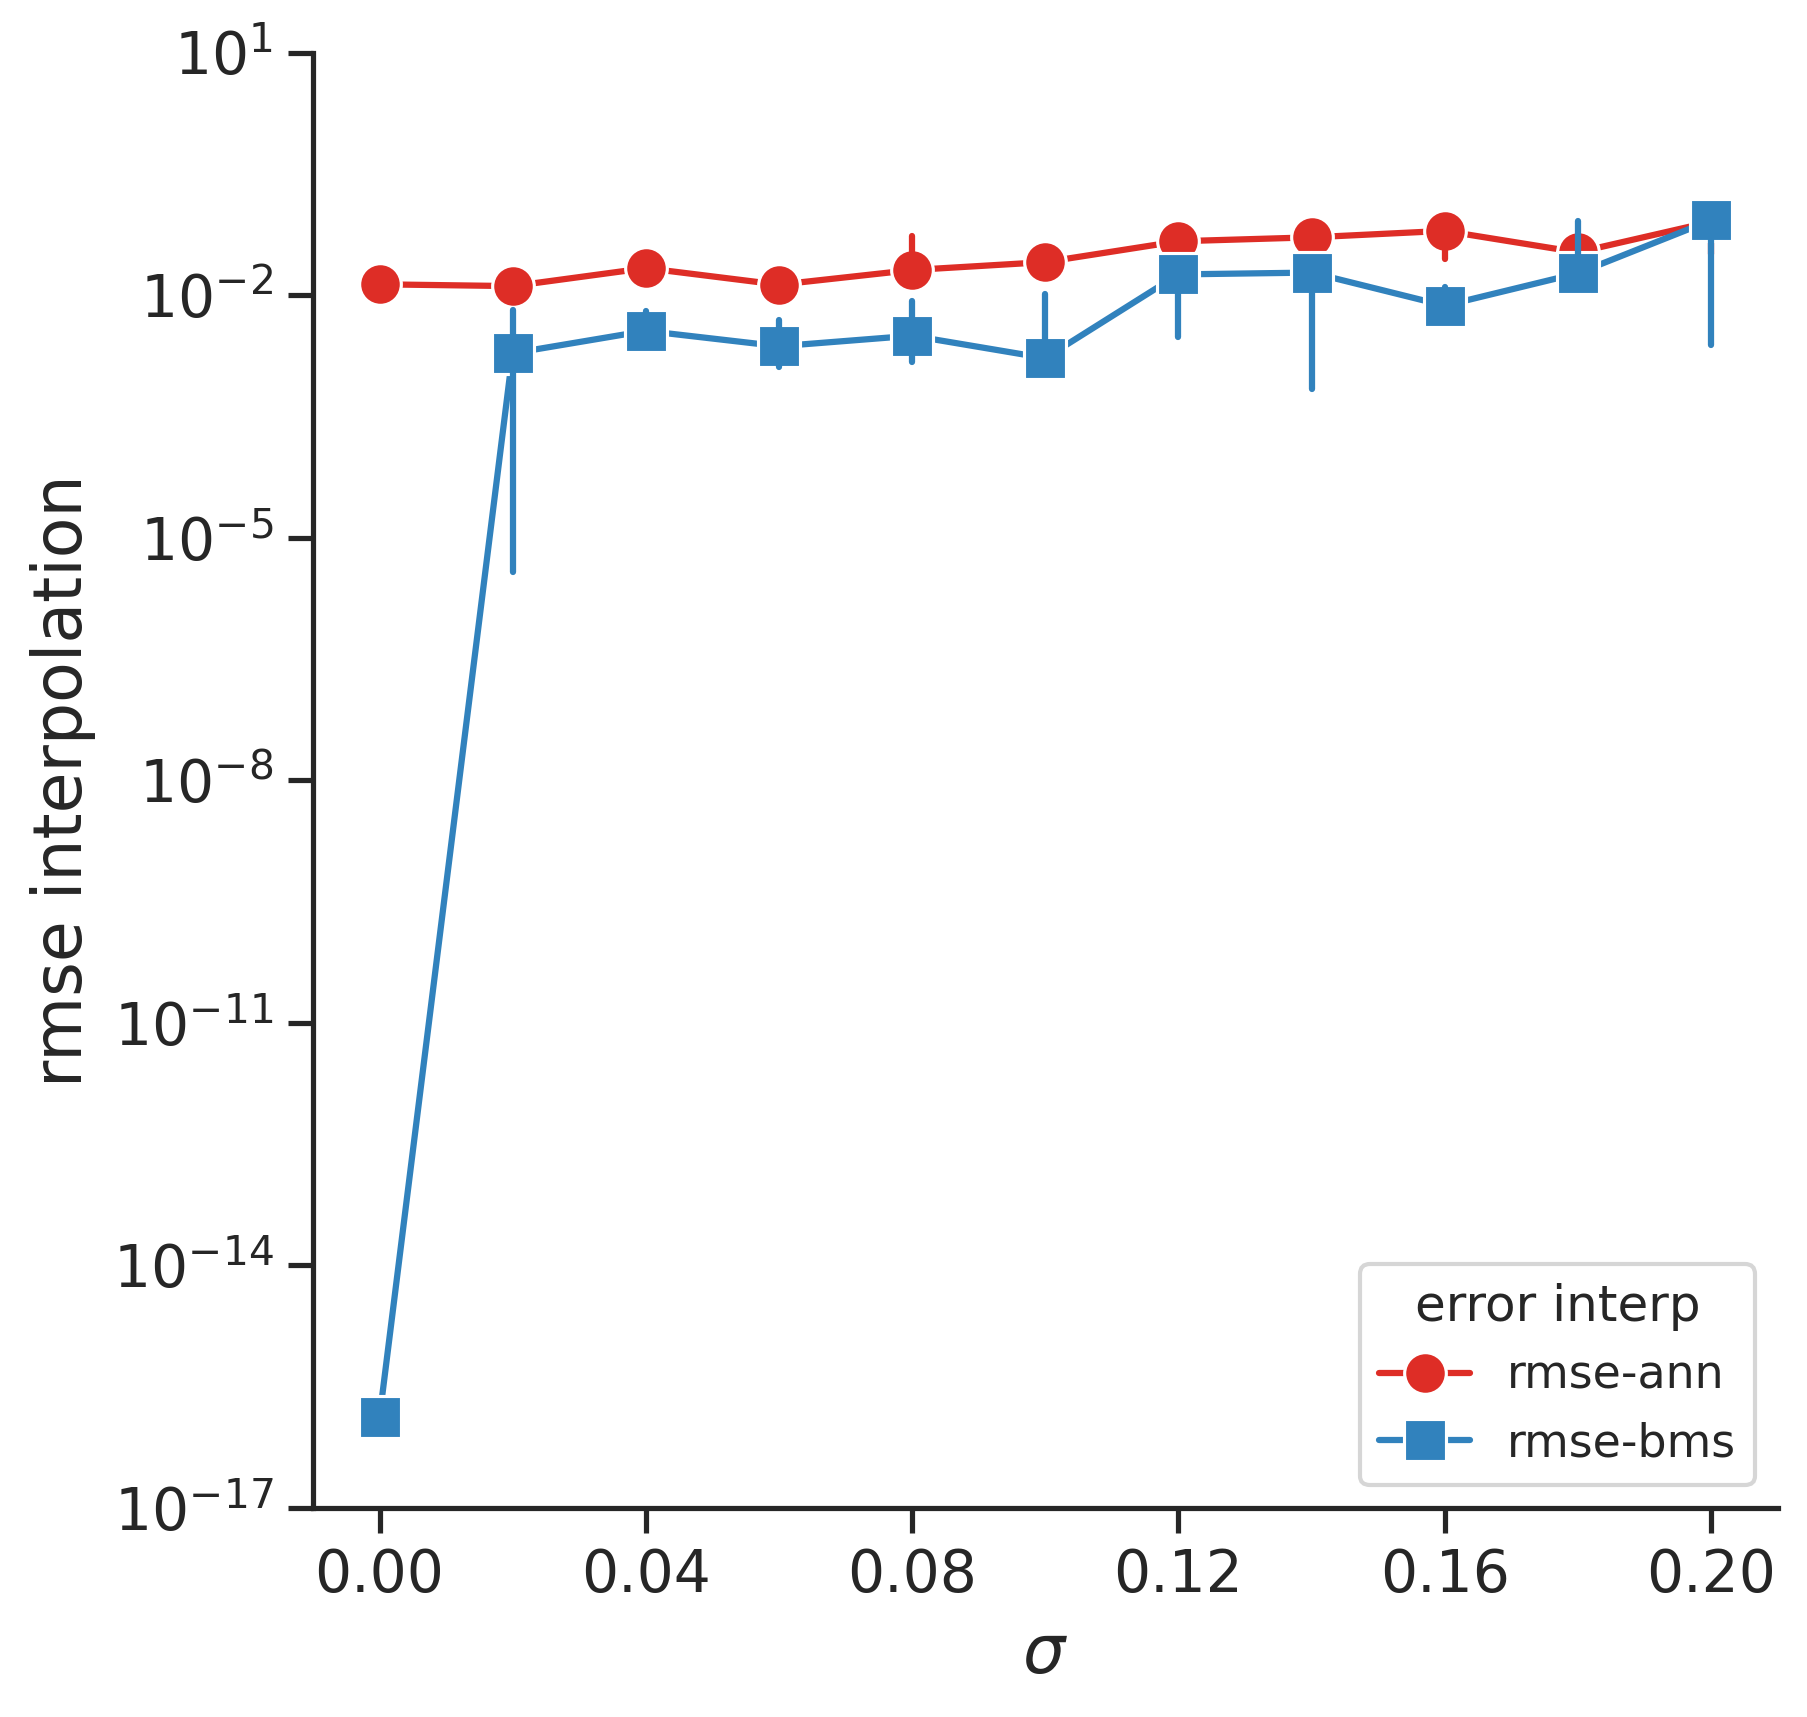

In [67]:
#interpolation
#-------------------------------------------------------------------------------------------------------------------
fig=figure(figsize=(width,height), dpi=300)
print(width, height)

display(errors_inter_plot)

sns.lineplot(
        data=errors_inter_plot, x='sigma', y='value_interp', hue='error interp', style='error interp',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_train'], markers['rmse_mdl_train']], dashes=False, markersize=m_size, legend="full", 
        palette=[color_ann, color_bms])

#labels, limits, and ticks
#plt.title(titles[func_number],fontsize=size_ticks)
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse interpolation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
xtick_labels=np.arange(0.0,0.22,0.04)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()
plt.ylim(ymin,ymax)

sns.despine()

namefig_inter='interpolation_' + str(n)
plt.savefig(output_path+namefig_inter + '.svg',dpi=300)
#-------------------------------------------------------------------------------------------------------------------

6.299212598425196 6.299212598425196


,sigma,function,r,error extrap,value_extrap
99,0.00,8,0,rmse-ann,0.011368
100,0.00,8,1,rmse-ann,0.025608
101,0.00,8,2,rmse-ann,0.037244
102,0.02,8,0,rmse-ann,0.061727
103,0.02,8,1,rmse-ann,0.051520
...,...,...,...,...,...
292,0.18,8,1,rmse-bms,0.028355
293,0.18,8,2,rmse-bms,0.072918
294,0.20,8,0,rmse-bms,0.117251
295,0.20,8,1,rmse-bms,0.096529


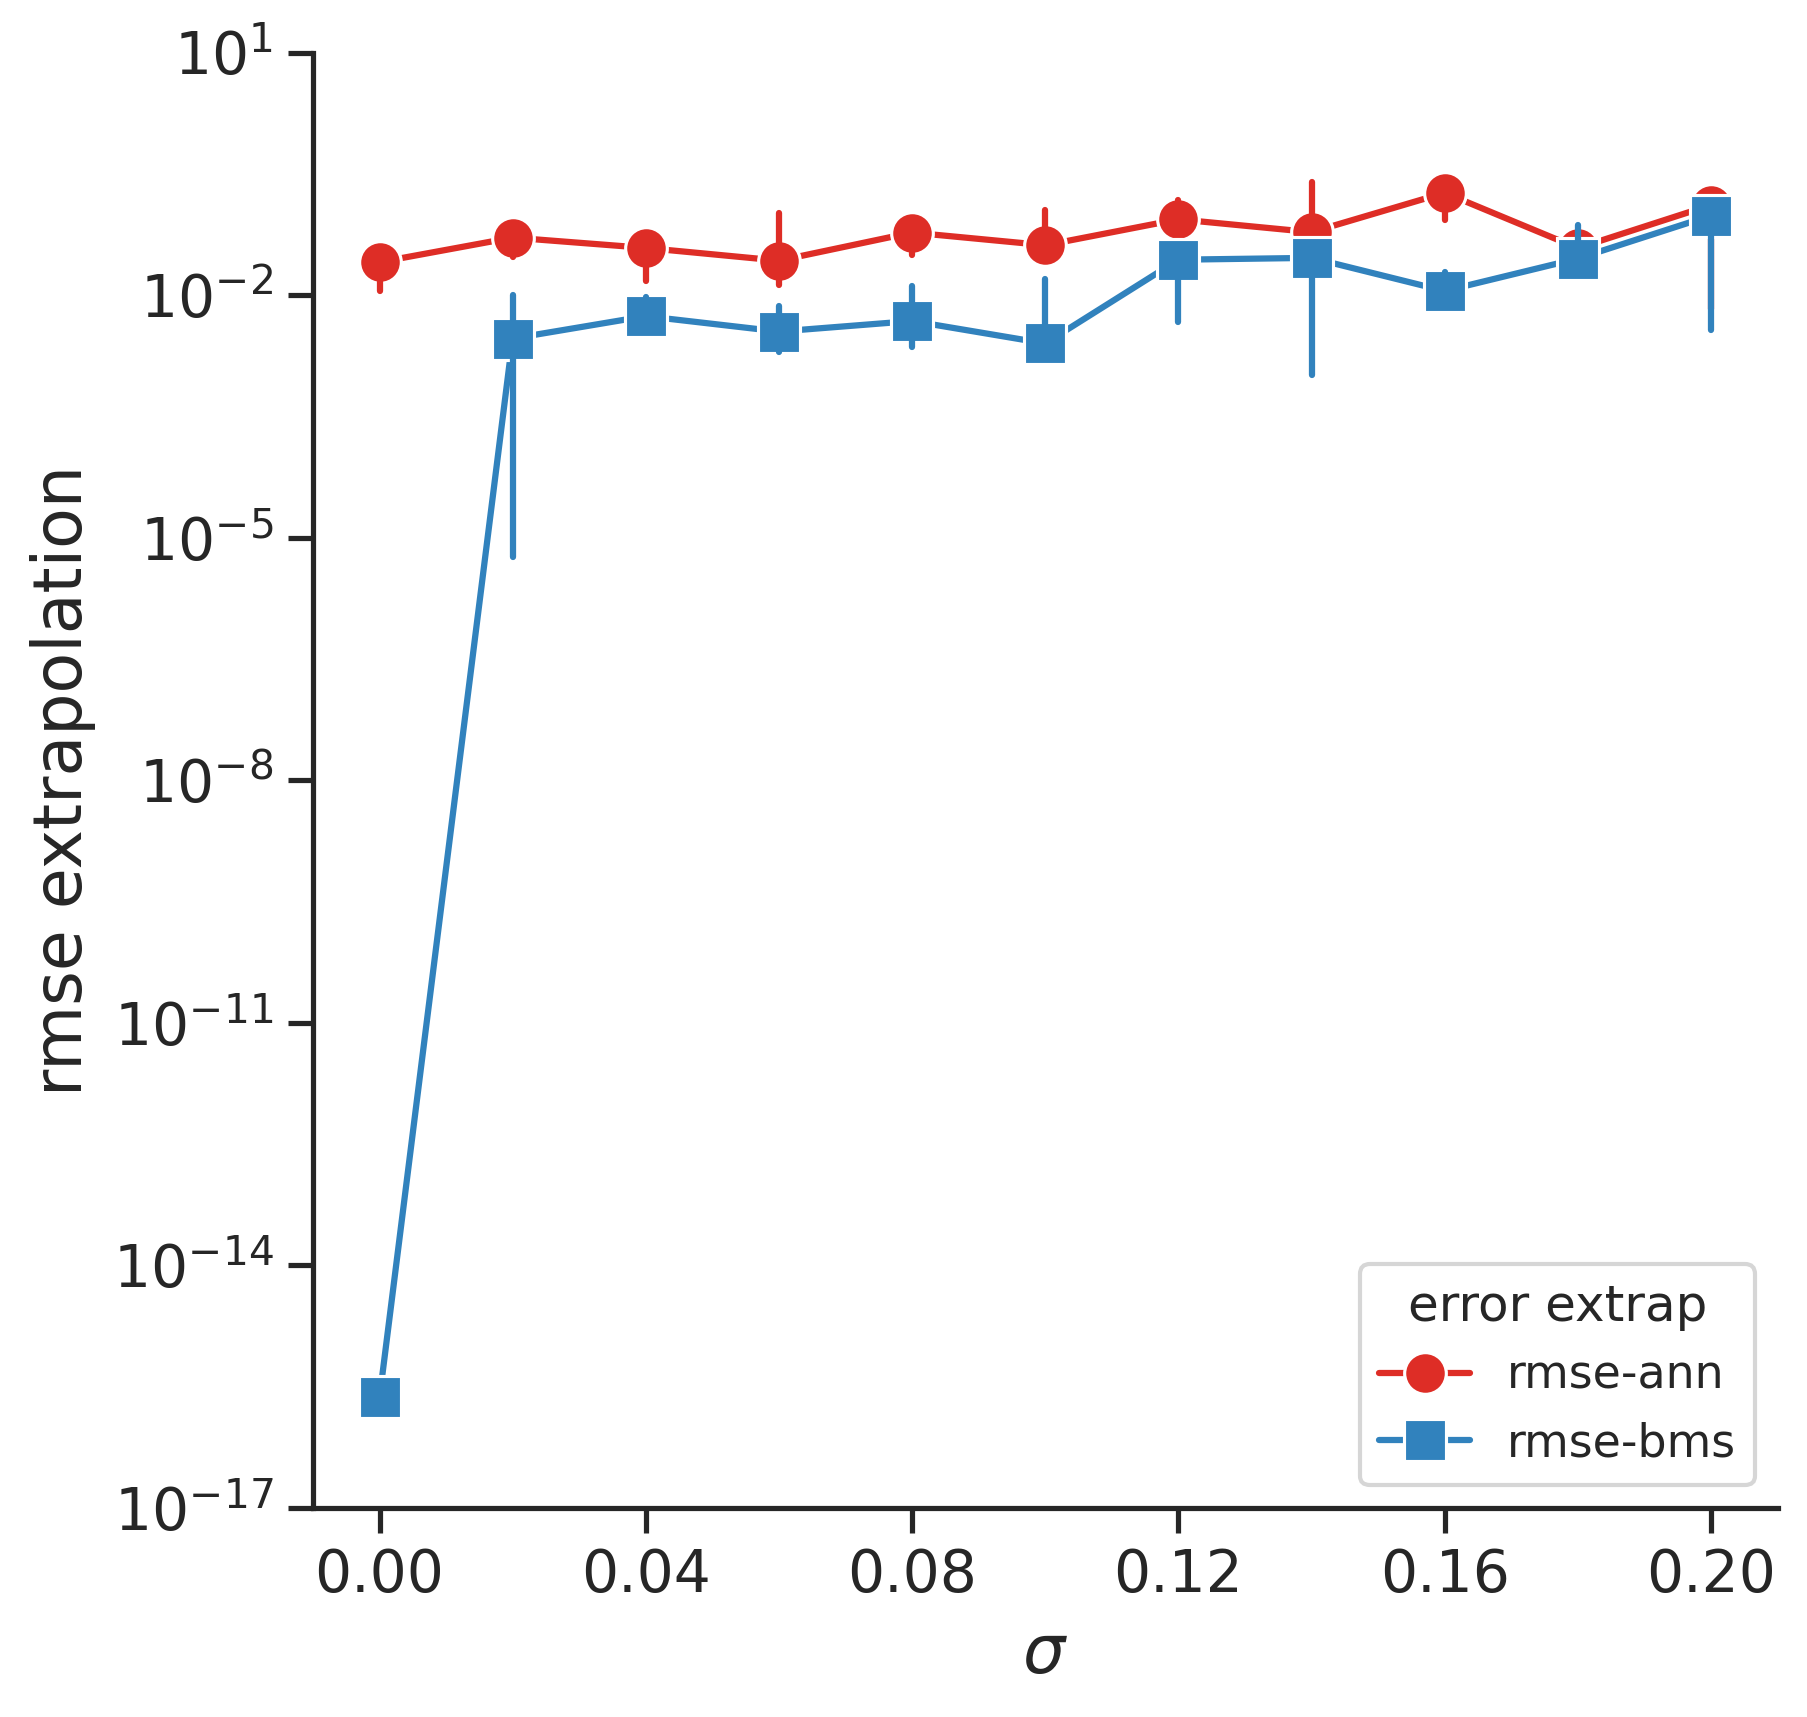

In [68]:
#Extrapolation
#-------------------------------------------------------------------------------------------------------------------
fig=figure(figsize=(width,height), dpi=300)
print(width, height)

display(errors_extra_plot)

sns.lineplot(
        data=errors_extra_plot, x='sigma', y='value_extrap', hue='error extrap', style='error extrap',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_train'], markers['rmse_mdl_train']], dashes=False, markersize=m_size, legend="full", 
        palette=[color_ann, color_bms])

#labels, limits, and ticks
#plt.title(titles[func_number],fontsize=size_ticks)
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse extrapolation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
xtick_labels=np.arange(0.0,0.22,0.04)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()
plt.ylim(ymin,ymax)

sns.despine()

namefig_extrap='extrapolation_' + str(n)
plt.savefig(output_path+namefig_extrap+ '.svg',dpi=300)
#-------------------------------------------------------------------------------------------------------------------